# Гипотезы H1/H2/H3 - объединенный запуск

Ноутбук полностью использует новый публичный API из `src.api` для:
1. Обучения DeepFM+SVD++ (если нужно)
2. Обучения DQN агента (если нужно)
3. Запуска всех трех гипотез H1/H2/H3 с одной команды
4. Визуализации метрик

## Метрики по гипотезам (соответствуют §6 `tests_section_6.md`)

| Гипотеза | Метрика | Описание |
|----------|---------|---------|
| **H1** | CDR, Retention Rate, Learning Slope, Final Coverage, Precision@K | Долгосрочная полезность: DQN vs Random / Popularity / DeepFM-SVD++ (Static), Welch t-test по CDR |
| **H2** | AdaptabilityScore, PrecisionStability, RecallStability, Precision@K, Recall@K, CDR | Стабильность по стратам (`Class`, `Semester`, `Lockdown`, демография) + ablation конфигураций состояния (`full_state`, `no_context`, `no_demo`, `no_context_no_demo`) |
| **H3** | Mean Reward, Novelty, Diversity, Coverage, Precision@K, Recall@K, F1@K, CDR | Ablation компонентов награды (`full`, `no_novelty`, `novelty_popularity`) + парный Welch t-тест |

## Быстрый старт

1. Заполните пути чекпоинтов или оставьте `None` для автоматического обучения
2. Запустите ячейки последовательно
3. Все метрики и графики сохранятся в `results/<run_name>/`

> **Альтернатива:** Если у вас уже есть обученные модели, используйте CLI:
> ```bash
> python -m src.cli evaluate --dataset itmrec --hypothesis all \
>     --deepfm-checkpoint data/models/deepfm_itmrec_best.pth \
>     --dqn-checkpoint data/models/dqn_itmrec_best.pth
> ```

In [7]:
from pathlib import Path
import sys
import json

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import api

# ============================================================================
# КОНФИГУРАЦИЯ
# ============================================================================
DATASET = "itmrec"  # "itmrec" или "oulad"

# Пути к обученным моделям (если None, модели будут обучены автоматически)
DEEPFM_CKPT = ROOT / "data" / "models" / f"deepfm_{DATASET}_best.pth"
DQN_CKPT = ROOT / "data" / "models" / f"dqn_{DATASET}_best.pth"

# Если чекпоинты не существуют, можем обучить заново
TRAIN_IF_MISSING = True

# ============================================================================
# ИНИЦИАЛИЗАЦИЯ
# ============================================================================
config = api.build_config(DATASET, yaml_path=str(ROOT / "configs" / f"{DATASET}.yaml"))
run_dir = api.prepare_run(config, run_name=f"{DATASET}_hypotheses")
print("Run dir:", run_dir)
print(f"Dataset: {DATASET}")
print(f"Device: CPU/GPU автоматически")

# ============================================================================
# АВТОМАТИЧЕСКОЕ ОБУЧЕНИЕ (если нужно)
# ============================================================================
if TRAIN_IF_MISSING:
    if not DEEPFM_CKPT.exists():
        print("\n>>> Обучаю DeepFM+SVD++ (не найден чекпоинт)...")
        static_result = api.train_static(DATASET, config=config, run_dir=run_dir)
        DEEPFM_CKPT = Path(static_result["history"]["best_checkpoint"])
        print(f" DeepFM чекпоинт: {DEEPFM_CKPT}")
    
    if not DQN_CKPT.exists():
        print("\n>>> Обучаю DQN (не найден чекпоинт)...")
        dqn_result = api.train_dqn(
            DATASET, 
            config=config, 
            run_dir=run_dir,
            deepfm_checkpoint=str(DEEPFM_CKPT)
        )
        DQN_CKPT = Path(dqn_result["checkpoint"])
        print(f"DQN чекпоинт: {DQN_CKPT}")
else:
    if not DEEPFM_CKPT.exists() or not DQN_CKPT.exists():
        print("Чекпоинты не найдены! Установите TRAIN_IF_MISSING=True или предоставьте пути.")
        print(f"  DEEPFM_CKPT: {DEEPFM_CKPT}")
        print(f"  DQN_CKPT: {DQN_CKPT}")
        sys.exit(1)

2026-04-24 05:06:35 | INFO | rec_sys_edu | Запуск: results\itmrec_hypotheses_20260424_050635
Run dir: results\itmrec_hypotheses_20260424_050635
Dataset: itmrec
Device: CPU/GPU автоматически

>>> Обучаю DeepFM+SVD++ (не найден чекпоинт)...
2026-04-24 05:06:35 | INFO | rec_sys_edu | Processed-данные не найдены, пытаемся загрузить raw
Загрузка датасета irecsys/itmrec с Kaggle...
ЗАГРУЗКА ДАТАСЕТА ITM-REC
Загружено 5230 записей рейтингов
Загружено 476 пользователей
Загружено 70 предметов

Размеры загруженных таблиц:
- ratings: (5230, 9)
- users: (476, 4)
- items: (70, 4)
Валидация данных пройдена успешно
2026-04-24 05:06:36 | INFO | rec_sys_edu | Cold-start filter: 5230 -> 5230 ratings (min_user=3, min_item=2)
Датасет инициализирован:
  Пользователей: 454
  Предметов: 70
  Классов: 3
  Семестров: 2
  Периодов COVID: 3
  Записей рейтингов: 5230
2026-04-24 05:06:36 | INFO | rec_sys_edu | ITM-Rec bundle готов: {'dataset_type': 'itmrec', 'n_users': 454, 'n_items': 70, 'state_dim': 65, 'n_ratin

  8%|▊         | 16/200 [00:00<00:01, 151.77it/s]

Эпизод начат: User 79, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 189, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 299, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 247, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 271, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 249, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 385, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 324, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 292, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 64, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 224, Context {'class': 1, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 311, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 67, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 268, Cont

 16%|█▌        | 32/200 [00:00<00:02, 60.96it/s] 

Эпизод начат: User 403, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 326, Context {'class': 1, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 208, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 303, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 246, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 194, Context {'class': 2, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 212, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 324, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 448, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 346, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 184, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 302, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 201, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 396, C

...

 97%|█████████▋| 194/200 [00:05<00:00, 31.29it/s]

Эпизод начат: User 20, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 3, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 167, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 51, Context {'class': 2, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 157, Context {'class': 2, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 370, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 293, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 236, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 388, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 374, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 264, Context {'class': 2, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 98, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 443, Context {'class': 2, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 254, Contex

100%|██████████| 200/200 [00:05<00:00, 36.95it/s]

Эпизод начат: User 17, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 82, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 354, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 113, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 129, Context {'class': 2, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 83, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 364, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 42, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 397, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 342, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 261, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 394, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 181, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 108, Conte

Эпизод начат: User 239, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 176, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 219, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 438, Context {'class': 1, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 353, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 38, Context {'class': 1, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 333, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 208, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Чекпоинт сохранен: results\itmrec_hypotheses_20260424_050635\models\dqn_itmrec_checkpoint.pth
2026-04-24 05:06:50 | INFO | rec_sys_edu | DQN training completed: episodes=200, final epsilon=0.015, mean_reward=3.044
DQN чекпоинт: results\itmrec_hypotheses_20260424_050635\models\dqn_itmrec_checkpoint.pth


In [8]:
result = api.evaluate_system(
    DATASET,
    hypothesis="all",
    config=config,
    run_dir=run_dir,
    deepfm_checkpoint=str(DEEPFM_CKPT),
    dqn_checkpoint=str(DQN_CKPT),
)
list(result["results"].keys())

2026-04-24 05:07:15 | INFO | rec_sys_edu | Processed-данные не найдены, пытаемся загрузить raw
Загрузка датасета irecsys/itmrec с Kaggle...
Датасет загружен в: C:\Users\Nasty\.cache\kagglehub\datasets\irecsys\itmrec\versions\3
ЗАГРУЗКА ДАТАСЕТА ITM-REC
Загружено 5230 записей рейтингов
Загружено 476 пользователей
Загружено 70 предметов

Размеры загруженных таблиц:
- ratings: (5230, 9)
- users: (476, 4)
- items: (70, 4)
Валидация данных пройдена успешно
2026-04-24 05:07:16 | INFO | rec_sys_edu | Cold-start filter: 5230 -> 5230 ratings (min_user=3, min_item=2)
Датасет инициализирован:
  Пользователей: 454
  Предметов: 70
  Классов: 3
  Семестров: 2
  Периодов COVID: 3
  Записей рейтингов: 5230
2026-04-24 05:07:16 | INFO | rec_sys_edu | ITM-Rec bundle готов: {'dataset_type': 'itmrec', 'n_users': 454, 'n_items': 70, 'state_dim': 65, 'n_ratings_rows': 5230, 'target_columns': ['Rating', 'App', 'Data', 'Ease'], 'context_columns': ['Class_encoded', 'Semester_encoded', 'Lockdown_encoded'], 'cont

['users_sampled', 'H1', 'H2', 'H3']

## H1 - долгосрочная полезность (CDR / Retention Rate / Learning Slope / Final Coverage)

,CDR,Precision@10,Recall@10,F1@10,Retention_Rate,Learning_Slope,Coverage_Progress,Final_Coverage
model,,,,,,,,
DQN,2.5359,0.7883,0.8357,0.8052,0.9217,0.0012,1.0000,0.0519
Random,2.8926,0.7689,0.8478,0.7975,0.9011,-0.0024,0.9611,0.0557
Popularity,5.3637,0.2606,0.7802,0.3145,0.9333,-0.0000,0.2856,0.0143
DeepFM-SVD++ (Static),5.6537,0.2417,0.8468,0.3206,1.0000,-0.0000,0.2600,0.0143


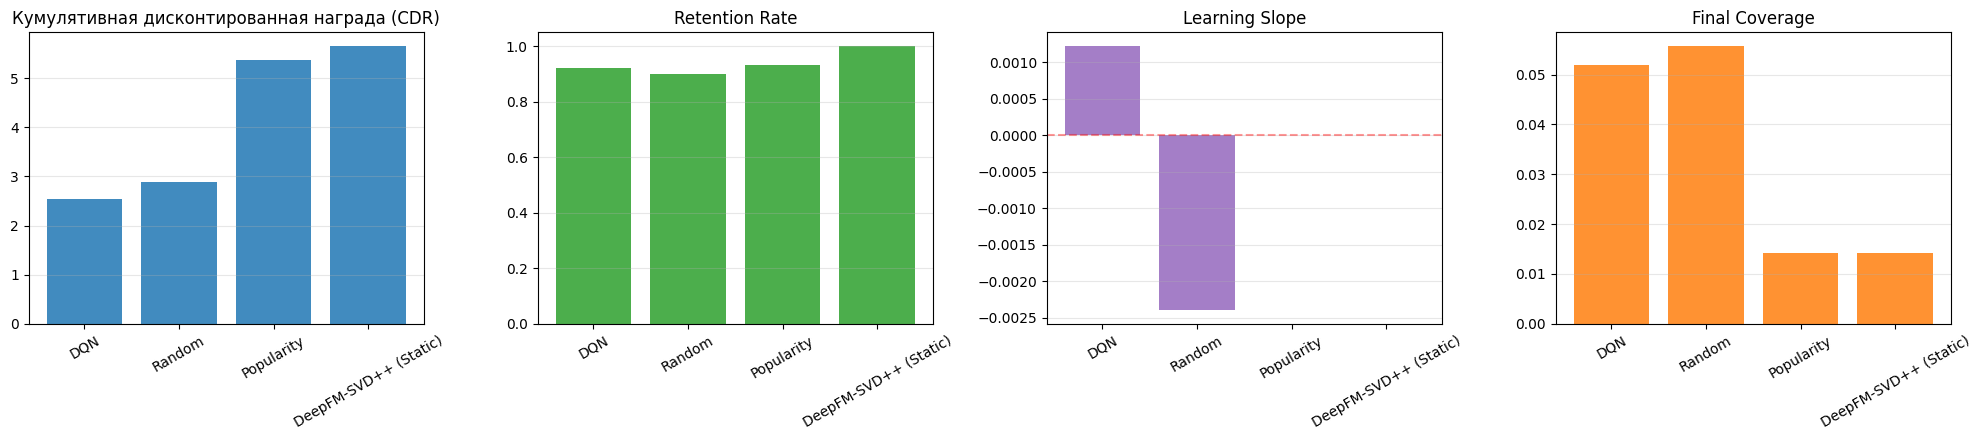


Статистика CDR vs DQN (Welch t-test):


,t_stat,p_value,significant,mean_diff
Random,-1.056289,0.295218,False,-0.356798
Popularity,-4.783014,0.000023,True,-2.827885
DeepFM-SVD++ (Static),-5.371135,0.000003,True,-3.117867



Порог Retention t_r = 0.5, K = 10


In [9]:
%matplotlib inline
import pandas as pd, json
import numpy as np
import matplotlib.pyplot as plt

h1 = result["results"].get("H1", {})
if h1:
    per_model = h1.get("per_model", {})
    rows = []
    for model_name, block in per_model.items():
        row = {"model": model_name, **block.get("mean", {})}
        rows.append(row)
    if rows:
        df_h1 = pd.DataFrame(rows).set_index("model")
        display(df_h1.round(4))
        # График по ключевым H1-метрикам
        fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
        metrics_plot = [
            ("CDR", "Кумулятивная дисконтированная награда (CDR)", "tab:blue"),
            ("Retention_Rate", "Retention Rate", "tab:green"),
            ("Learning_Slope", "Learning Slope", "tab:purple"),
            ("Final_Coverage", "Final Coverage", "tab:orange"),
        ]
        models = df_h1.index.tolist()
        for ax, (col, title, color) in zip(axes, metrics_plot):
            values = df_h1[col].to_numpy() if col in df_h1.columns else np.zeros(len(models))
            ax.bar(models, values, color=color, alpha=0.85)
            ax.set_title(title)
            ax.tick_params(axis="x", rotation=30)
            if col == "Learning_Slope":
                ax.axhline(y=0, color="red", linestyle="--", alpha=0.4)
            ax.grid(True, alpha=0.3, axis="y")
        plt.tight_layout()
        plt.show()
    sig = h1.get("significance_cdr", {})
    if sig:
        print("\nСтатистика CDR vs DQN (Welch t-test):")
        display(pd.DataFrame(sig).T.round(4))
    print(f"\nПорог Retention t_r = {h1.get('retention_threshold', 0.5)}, K = {h1.get('k', 10)}")
else:
    print("Нет данных H1 - возможно, evaluate_system был запущен без H1.")

## H2 - адаптивность: AdaptabilityScore, sigma_P, sigma_R по стратам и конфигурациям состояния

,value
adaptability_score,0.9239
learning_slope,-0.0008
precision_stability,0.0744
recall_stability,0.0778
per_user_precision,0.1228
per_user_recall,0.1029



Сегментный анализ (стратификация по контексту / демографии):

Class_encoded:


,precision,recall,mean_reward,n_users
0,0.0500,0.0388,0.6017,13.0
1,0.1815,0.2086,0.6716,9.0
2,0.1750,0.0883,0.6573,8.0



Semester_encoded:


,precision,recall,mean_reward,n_users
0,0.1492,0.1288,0.6560,22.0
1,0.0500,0.0317,0.5868,8.0



Lockdown_encoded:


,precision,recall,mean_reward,n_users
0,0.0000,0.0000,0.3929,1.0
1,0.2259,0.2233,0.6956,9.0
2,0.0825,0.0539,0.6236,20.0



Ablation по конфигурациям состояния (full_state / no_context / no_demo / ...):


,AdaptabilityScore,PrecisionStability,RecallStability,Precision@K,Recall@K,CDR
state_ablation,,,,,,
full_state,0.9193,0.0798,0.0816,0.1167,0.0843,2.8932
no_context,0.9501,0.0525,0.0473,0.0894,0.0483,2.3263
no_demo,0.9009,0.1088,0.0895,0.1228,0.0940,2.7266
no_context_no_demo,0.9174,0.0887,0.0764,0.1128,0.0839,2.3063


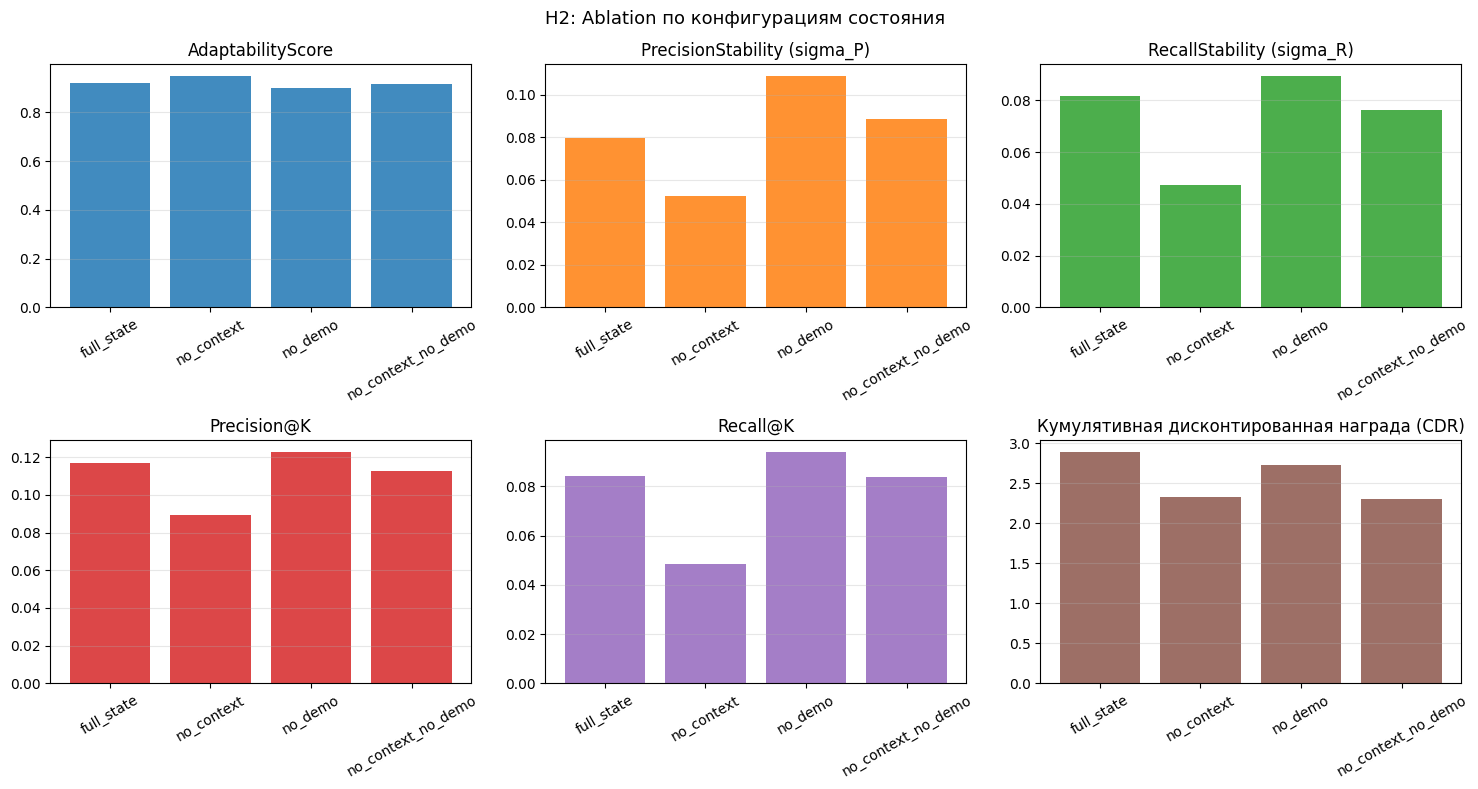

In [10]:
%matplotlib inline
h2 = result["results"].get("H2", {})
if h2:
    scalar_keys = [
        "adaptability_score",
        "learning_slope",
        "precision_stability",
        "recall_stability",
        "per_user_precision",
        "per_user_recall",
    ]
    scalar_row = {k: h2.get(k, 0.0) for k in scalar_keys}
    display(pd.DataFrame([scalar_row]).T.rename(columns={0: "value"}).round(4))

    by_strata = h2.get("by_strata", {})
    if by_strata:
        print("\nСегментный анализ (стратификация по контексту / демографии):")
        for stratum_col, stratum_table in by_strata.items():
            df_strat = pd.DataFrame(stratum_table).T
            print(f"\n{stratum_col}:")
            display(df_strat.round(4))
    else:
        print("\n(страты отсутствуют - проверьте strata_columns / состав bundle)")

    state_abl = h2.get("state_ablation", {})
    if state_abl:
        print("\nAblation по конфигурациям состояния (full_state / no_context / no_demo / ...):")
        rows = []
        for mode, payload in state_abl.items():
            rows.append({
                "state_ablation": mode,
                "AdaptabilityScore": payload.get("adaptability_score", 0.0),
                "PrecisionStability": payload.get("precision_stability", 0.0),
                "RecallStability": payload.get("recall_stability", 0.0),
                "Precision@K": payload.get("per_user_precision", 0.0),
                "Recall@K": payload.get("per_user_recall", 0.0),
                "CDR": payload.get("cdr", 0.0),
            })
        df_state = pd.DataFrame(rows).set_index("state_ablation")
        display(df_state.round(4))
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        metrics_plot = [
            ("AdaptabilityScore", "AdaptabilityScore", "tab:blue"),
            ("PrecisionStability", "PrecisionStability (sigma_P)", "tab:orange"),
            ("RecallStability", "RecallStability (sigma_R)", "tab:green"),
            ("Precision@K", "Precision@K", "tab:red"),
            ("Recall@K", "Recall@K", "tab:purple"),
            ("CDR", "Кумулятивная дисконтированная награда (CDR)", "tab:brown"),
        ]
        for ax, (col, title, color) in zip(axes.flatten(), metrics_plot):
            ax.bar(df_state.index, df_state[col].to_numpy(), color=color, alpha=0.85)
            ax.set_title(title)
            ax.tick_params(axis="x", rotation=30)
            ax.grid(True, alpha=0.3, axis="y")
        fig.suptitle("H2: Ablation по конфигурациям состояния", fontsize=13)
        plt.tight_layout()
        plt.show()
else:
    print("Нет данных H2.")

## H3 - ablation новизны (Novelty / Diversity / Coverage / P@K / R@K / F1@K / CDR)

,mean_reward,std_reward,mean_novelty,mean_diversity,n_episodes,precision@10,recall@10,f1@10,coverage,cdr
variant,,,,,,,,,,
full,3.1032,0.4406,0.9102,1.0,10,0.08,0.0734,0.0691,0.0657,3.0673
no_novelty,2.5199,0.6767,0.9159,1.0,10,0.06,0.0401,0.0441,0.0600,2.6071
novelty_popularity,2.7325,0.7408,0.7070,1.0,10,0.16,0.0734,0.0824,0.0657,2.9517


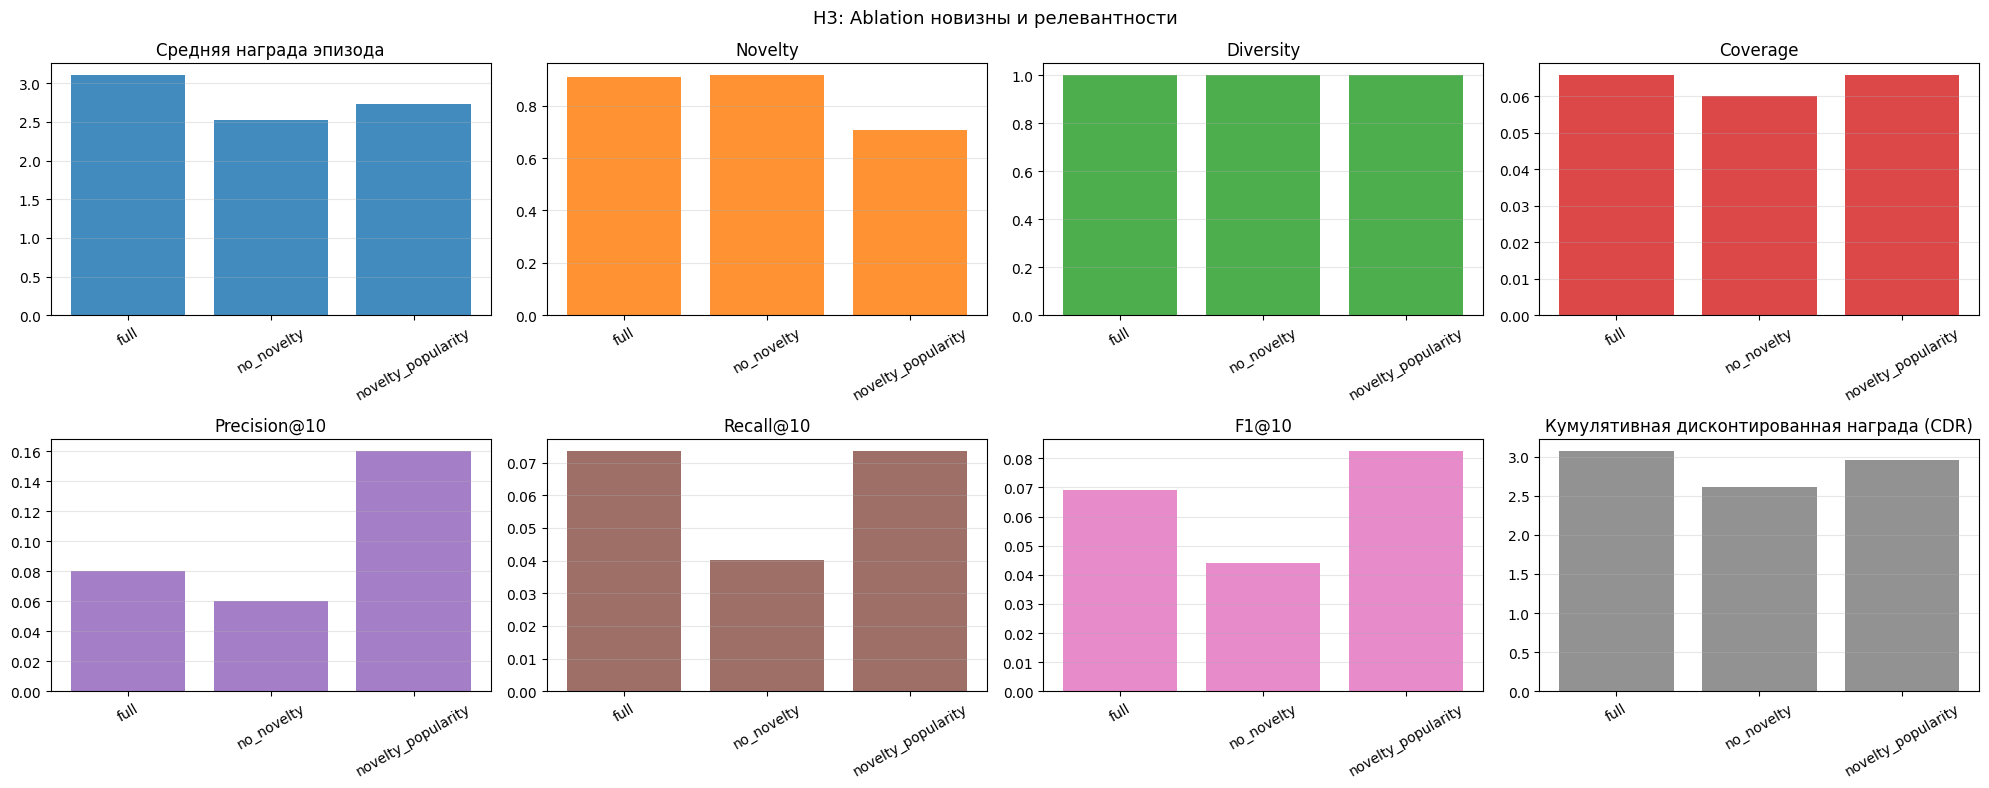


Парный тест (Welch) vs variant='full':


,name,statistic,p_value,significant,effect_size,n
no_novelty,full_vs_no_novelty,2.167175,0.046207,True,0.96919,20
novelty_popularity,full_vs_novelty_popularity,1.29029,0.216931,False,0.577035,20



Полный отчет: results\itmrec_hypotheses_20260424_050635\tables\evaluation_summary.json


In [11]:
%matplotlib inline
h3 = result["results"].get("H3", {})
if h3:
    ablation = h3.get("ablation", [])
    extra = h3.get("extra_metrics", {})
    if ablation:
        df_ablation = pd.DataFrame(ablation)
        if "episode_rewards" in df_ablation.columns:
            df_ablation = df_ablation.drop(columns=["episode_rewards"])
        df_ablation = df_ablation.set_index("variant")
        if extra:
            extra_df = pd.DataFrame(extra).T
            df_ablation = df_ablation.join(extra_df, how="left")
        display(df_ablation.round(4))

        import matplotlib.pyplot as plt
        variants = df_ablation.index.tolist()
        k_cols = [c for c in df_ablation.columns if c.startswith('precision@')]
        k_value = k_cols[0].split('@')[1] if k_cols else '10'
        metrics_plot = [
            ("mean_reward", "Средняя награда эпизода", "tab:blue"),
            ("mean_novelty", "Novelty", "tab:orange"),
            ("mean_diversity", "Diversity", "tab:green"),
            ("coverage", "Coverage", "tab:red"),
            (f"precision@{k_value}", f"Precision@{k_value}", "tab:purple"),
            (f"recall@{k_value}", f"Recall@{k_value}", "tab:brown"),
            (f"f1@{k_value}", f"F1@{k_value}", "tab:pink"),
            ("cdr", "Кумулятивная дисконтированная награда (CDR)", "tab:gray"),
        ]
        fig, axes = plt.subplots(2, 4, figsize=(20, 8))
        for ax, (col, title, color) in zip(axes.flatten(), metrics_plot):
            if col in df_ablation.columns:
                vals = df_ablation[col].to_numpy()
            else:
                vals = [0.0] * len(variants)
            ax.bar(variants, vals, color=color, alpha=0.85)
            ax.set_title(title)
            ax.tick_params(axis="x", rotation=30)
            ax.grid(True, alpha=0.3, axis="y")
        fig.suptitle("H3: Ablation новизны и релевантности", fontsize=13)
        plt.tight_layout()
        plt.show()

    pairwise = h3.get("pairwise_vs_full", {})
    if pairwise:
        print("\nПарный тест (Welch) vs variant='full':")
        display(pd.DataFrame(pairwise).T.round(4))
    summary_path = Path(run_dir) / "tables" / "evaluation_summary.json"
    if summary_path.exists():
        print("\nПолный отчет:", summary_path)